# KRR vs IWKRR vs Pseudo-Label KRR under Covariate Shift

Data generation follows this project (`KRR.py`):
- source: `B/(B+1) U[0,1/2] + 1/(B+1) U[1/2,1]`
- target: `1/(B+1) U[0,1/2] + B/(B+1) U[1/2,1]`
- `f*(x)=cos(2*pi*x)-1`, `y=f*(x)+noise`

Methods compared by `L2(Q)` norm:
- KRR (validation-tuned)
- IWKRR (validation-tuned)
- `KRR_covariate_shift` from `KRR.py` (pseudo-label selection)


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.kernel_ridge import KernelRidge

from KRR import KRR_covariate_shift, f_star


In [15]:
# Common setup (project-aligned)
GLOBAL_SEED = 2026
rng0 = np.random.default_rng(GLOBAL_SEED)

# data generation settings
B = 5.0
fcn = 'C'
sigma = 1.0

# experiment settings
N_REP = 200
N_TRAIN = 500
N_VAL = 400
N_TARGET_UNLAB = N_TRAIN + N_VAL  # match total source labeled size for fairness
N_TEST_Q = 4000

LAMBDA_GRID = np.array([1e-08, 3e-08, 1e-07, 3e-07, 1e-06, 3e-06, 1e-05, 3e-05, 0.0001])

# kernel settings for KRR/IWKRR baselines
KERNEL = 'rbf'
GAMMA = 0.3

print('Setup ready. reps =', N_REP, ', lambda grid size =', len(LAMBDA_GRID))



Setup ready. reps = 200 , lambda grid size = 9


In [16]:
# Source/target samplers and densities from this project
def sample_source(n, B, rng):
    n_left = int(n * B / (B + 1))
    x_left = rng.random(n_left) / 2
    x_right = 0.5 + rng.random(n - n_left) / 2
    x = np.concatenate([x_left, x_right])
    rng.shuffle(x)
    return x

def sample_target(n, B, rng):
    n_right = int(n * B / (B + 1))
    x_left = rng.random(n - n_right) / 2
    x_right = 0.5 + rng.random(n_right) / 2
    x = np.concatenate([x_left, x_right])
    rng.shuffle(x)
    return x

def p_density(x, B):
    x = np.asarray(x)
    left = 2 * B / (B + 1)
    right = 2 / (B + 1)
    return np.where((x >= 0) & (x <= 0.5), left, np.where((x > 0.5) & (x <= 1.0), right, 0.0))

def q_density(x, B):
    x = np.asarray(x)
    left = 2 / (B + 1)
    right = 2 * B / (B + 1)
    return np.where((x >= 0) & (x <= 0.5), left, np.where((x > 0.5) & (x <= 1.0), right, 0.0))

def l2q_norm(y_pred, y_true):
    return np.sqrt(np.mean((y_pred - y_true) ** 2))


In [17]:
# One-repetition runner
def run_one_rep(seed):
    rng = np.random.default_rng(seed)

    # full labeled source then split into train/validation (hold-out)
    x_full = sample_source(N_TRAIN + N_VAL, B, rng)
    y_full = f_star(x_full, fcn) + sigma * rng.standard_normal(N_TRAIN + N_VAL)

    x_tr = x_full[:N_TRAIN]
    y_tr = y_full[:N_TRAIN]
    x_val = x_full[N_TRAIN:]
    y_val = y_full[N_TRAIN:]

    x_q_test = sample_target(N_TEST_Q, B, rng)
    y_q_test_true = f_star(x_q_test, fcn)

    # -------- KRR: validation tuning on source hold-out labels --------
    best_krr_lam = None
    best_krr_val = np.inf
    best_krr_model = None
    for lam in LAMBDA_GRID:
        model = KernelRidge(kernel=KERNEL, alpha=lam, gamma=GAMMA)
        model.fit(x_tr.reshape(-1, 1), y_tr)
        val_pred = model.predict(x_val.reshape(-1, 1))
        val_loss = np.mean((val_pred - y_val) ** 2)
        if val_loss < best_krr_val:
            best_krr_val = val_loss
            best_krr_lam = lam
            best_krr_model = model

    krr_pred_q = best_krr_model.predict(x_q_test.reshape(-1, 1))
    err_krr = l2q_norm(krr_pred_q, y_q_test_true)

    # -------- IWKRR: weighted validation tuning on source hold-out labels --------
    w_val = q_density(x_val, B) / np.maximum(p_density(x_val, B), 1e-12)
    best_iwkrr_lam = None
    best_iwkrr_val = np.inf
    best_iwkrr_model = None
    for lam in LAMBDA_GRID:
        model = KernelRidge(kernel=KERNEL, alpha=lam, gamma=GAMMA)
        model.fit(x_tr.reshape(-1, 1), y_tr)
        val_pred = model.predict(x_val.reshape(-1, 1))
        val_loss = np.mean(w_val * (val_pred - y_val) ** 2)
        if val_loss < best_iwkrr_val:
            best_iwkrr_val = val_loss
            best_iwkrr_lam = lam
            best_iwkrr_model = model

    iwkrr_pred_q = best_iwkrr_model.predict(x_q_test.reshape(-1, 1))
    err_iwkrr = l2q_norm(iwkrr_pred_q, y_q_test_true)

    # -------- Pseudo-label KRR in KRR.py --------
    # It internally splits source, builds pseudo labels on unlabeled target, and selects lambda.
    cs = KRR_covariate_shift(n=N_TRAIN + N_VAL, n_0=N_TARGET_UNLAB, B=B, sigma=sigma, fcn=fcn, seed=seed)
    cs.fit(beta=2)
    cs.predict_final(x_q_test)
    err_cs = l2q_norm(cs.y_new_pseudo, y_q_test_true)

    return {
        'krr': err_krr,
        'iwkrr': err_iwkrr,
        'cs_pseudo': err_cs,
        'lam_krr': best_krr_lam,
        'lam_iwkrr': best_iwkrr_lam,
    }




In [18]:
# Run repeated comparison
res_krr = []
res_iwkrr = []
res_cs = []
lam_krr_list = []
lam_iwkrr_list = []

for rep in range(N_REP):
    seed = 10000 + rep
    out = run_one_rep(seed)
    res_krr.append(out['krr'])
    res_iwkrr.append(out['iwkrr'])
    res_cs.append(out['cs_pseudo'])
    lam_krr_list.append(out['lam_krr'])
    lam_iwkrr_list.append(out['lam_iwkrr'])

res_krr = np.array(res_krr)
res_iwkrr = np.array(res_iwkrr)
res_cs = np.array(res_cs)
lam_krr_list = np.array(lam_krr_list)
lam_iwkrr_list = np.array(lam_iwkrr_list)

print(f'Finished {N_REP} repetitions.')


Finished 200 repetitions.


In [19]:
# Summary
def summarize(name, arr):
    print(f"{name}: mean={arr.mean():.4f}, std={arr.std():.4f}, min={arr.min():.4f}, max={arr.max():.4f}")

print('===== L2(Q) norm summary =====')
summarize('KRR', res_krr)
summarize('IWKRR', res_iwkrr)
summarize('KRR_covariate_shift (pseudo)', res_cs)

print('')
print('===== selected lambdas =====')
print('KRR unique lambdas:', np.unique(lam_krr_list))
print('IWKRR unique lambdas:', np.unique(lam_iwkrr_list))


===== L2(Q) norm summary =====
KRR: mean=0.1399, std=0.0573, min=0.0378, max=0.3133
IWKRR: mean=0.1431, std=0.0574, min=0.0351, max=0.3133
KRR_covariate_shift (pseudo): mean=0.1803, std=0.0588, min=0.0608, max=0.3541

===== selected lambdas =====
KRR unique lambdas: [1.e-08 3.e-08 1.e-07 3.e-07 1.e-06 3.e-06 1.e-05 3.e-05 1.e-04]
IWKRR unique lambdas: [1.e-08 3.e-08 1.e-07 3.e-07 1.e-06 3.e-06 1.e-05 3.e-05 1.e-04]


Most selected lambda (KRR): 1e-08 | count = 35 / 200
Most selected lambda (IWKRR): 1e-08 | count = 48 / 200

KRR lambda frequency:
  lambda=1e-08: 35
  lambda=3e-08: 16
  lambda=1e-07: 10
  lambda=3e-07: 12
  lambda=1e-06: 23
  lambda=3e-06: 32
  lambda=1e-05: 31
  lambda=3e-05: 30
  lambda=0.0001: 11

IWKRR lambda frequency:
  lambda=1e-08: 48
  lambda=3e-08: 16
  lambda=1e-07: 14
  lambda=3e-07: 10
  lambda=1e-06: 23
  lambda=3e-06: 17
  lambda=1e-05: 26
  lambda=3e-05: 24
  lambda=0.0001: 22


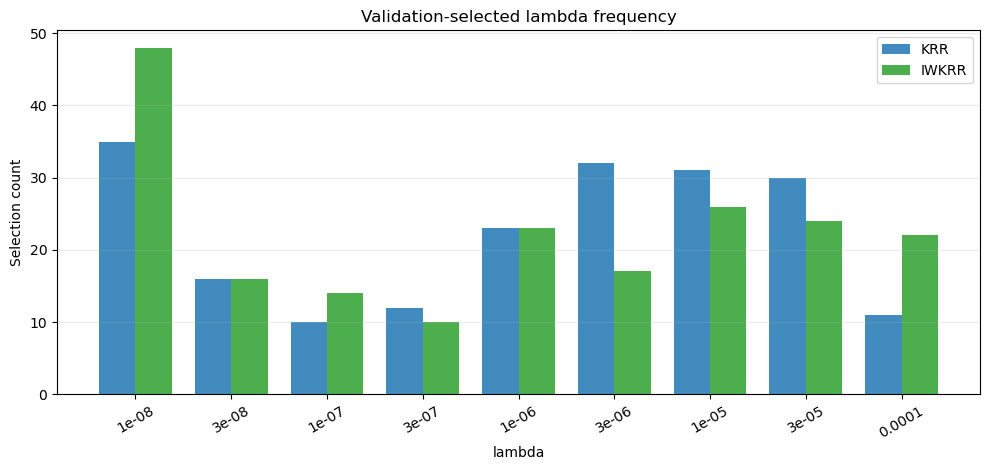

In [20]:
# Optimal lambda display (KRR / IWKRR)
def lambda_freq(arr):
    vals, cnts = np.unique(arr, return_counts=True)
    order = np.argsort(vals)
    return vals[order], cnts[order]

vals_krr, cnts_krr = lambda_freq(lam_krr_list)
vals_iw, cnts_iw = lambda_freq(lam_iwkrr_list)

best_krr = vals_krr[np.argmax(cnts_krr)]
best_iw = vals_iw[np.argmax(cnts_iw)]

print('Most selected lambda (KRR):', best_krr, '| count =', cnts_krr.max(), '/', len(lam_krr_list))
print('Most selected lambda (IWKRR):', best_iw, '| count =', cnts_iw.max(), '/', len(lam_iwkrr_list))
print('')
print('KRR lambda frequency:')
for v, c in zip(vals_krr, cnts_krr):
    print(f'  lambda={v:g}: {c}')
print('')
print('IWKRR lambda frequency:')
for v, c in zip(vals_iw, cnts_iw):
    print(f'  lambda={v:g}: {c}')

# bar chart
labels = [f'{v:g}' for v in LAMBDA_GRID]
krr_map = {v:c for v,c in zip(vals_krr,cnts_krr)}
iw_map = {v:c for v,c in zip(vals_iw,cnts_iw)}
krr_bar = np.array([krr_map.get(v,0) for v in LAMBDA_GRID])
iw_bar = np.array([iw_map.get(v,0) for v in LAMBDA_GRID])

x = np.arange(len(LAMBDA_GRID))
w = 0.38
plt.figure(figsize=(10,4.8))
plt.bar(x-w/2, krr_bar, width=w, label='KRR', color='tab:blue', alpha=0.85)
plt.bar(x+w/2, iw_bar, width=w, label='IWKRR', color='tab:green', alpha=0.85)
plt.xticks(x, labels, rotation=30)
plt.xlabel('lambda')
plt.ylabel('Selection count')
plt.title('Validation-selected lambda frequency')
plt.legend()
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()


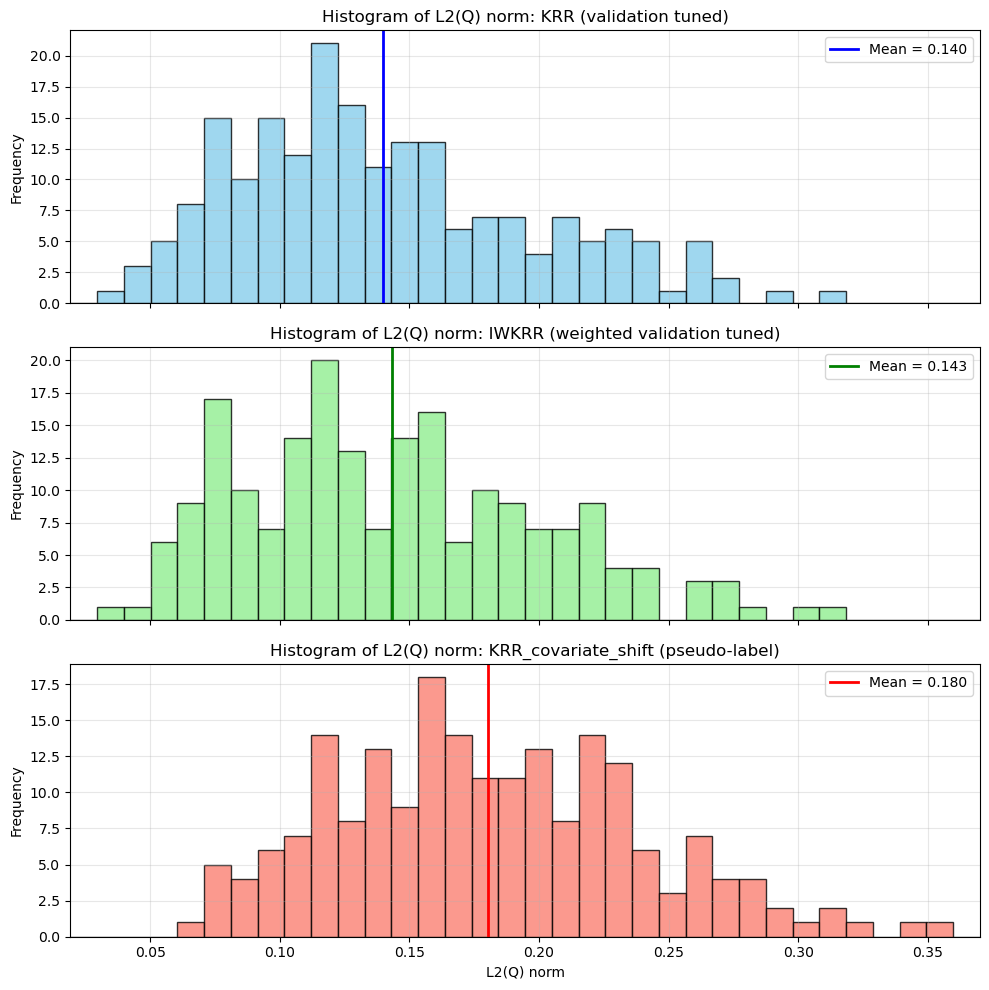

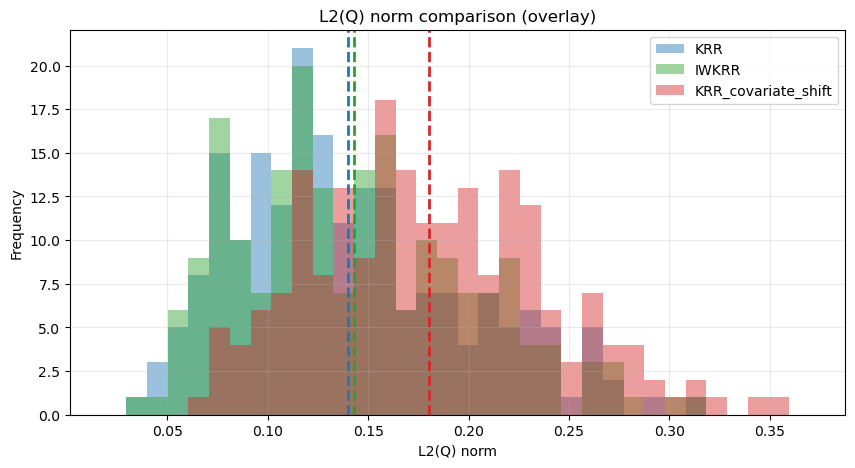

In [21]:
# Comparison plots (style aligned with KRR-CS-note-project-data.ipynb)
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

x_min = min(res_krr.min(), res_iwkrr.min(), res_cs.min())
x_max = max(res_krr.max(), res_iwkrr.max(), res_cs.max())
pad = 0.05 * (x_max - x_min if x_max > x_min else 1.0)
x_min -= pad
x_max += pad
bins = np.linspace(x_min, x_max, 35)

axes[0].hist(res_krr, bins=bins, color='skyblue', edgecolor='black', alpha=0.8)
axes[0].axvline(res_krr.mean(), color='blue', linestyle='-', linewidth=2, label=f"Mean = {res_krr.mean():.3f}")
axes[0].set_title('Histogram of L2(Q) norm: KRR (validation tuned)')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(res_iwkrr, bins=bins, color='lightgreen', edgecolor='black', alpha=0.8)
axes[1].axvline(res_iwkrr.mean(), color='green', linestyle='-', linewidth=2, label=f"Mean = {res_iwkrr.mean():.3f}")
axes[1].set_title('Histogram of L2(Q) norm: IWKRR (weighted validation tuned)')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].hist(res_cs, bins=bins, color='salmon', edgecolor='black', alpha=0.8)
axes[2].axvline(res_cs.mean(), color='red', linestyle='-', linewidth=2, label=f"Mean = {res_cs.mean():.3f}")
axes[2].set_title('Histogram of L2(Q) norm: KRR_covariate_shift (pseudo-label)')
axes[2].set_xlabel('L2(Q) norm')
axes[2].set_ylabel('Frequency')
axes[2].set_xlim(x_min, x_max)
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# one-panel overlay
plt.figure(figsize=(10, 5))
plt.hist(res_krr, bins=bins, alpha=0.45, label='KRR', color='tab:blue')
plt.hist(res_iwkrr, bins=bins, alpha=0.45, label='IWKRR', color='tab:green')
plt.hist(res_cs, bins=bins, alpha=0.45, label='KRR_covariate_shift', color='tab:red')
plt.axvline(res_krr.mean(), color='tab:blue', linestyle='--', linewidth=2)
plt.axvline(res_iwkrr.mean(), color='tab:green', linestyle='--', linewidth=2)
plt.axvline(res_cs.mean(), color='tab:red', linestyle='--', linewidth=2)
plt.title('L2(Q) norm comparison (overlay)')
plt.xlabel('L2(Q) norm')
plt.ylabel('Frequency')
plt.legend()
plt.grid(alpha=0.25)
plt.show()
